**FIFA World Cup Data Analyst**

In [ ]:
# Step 1: Impor Pustaka
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Step 2: Load Dataset
from google.colab import files
uploaded = files.upload()  # Upload your 'WorldCupMatches.csv' file
df = pd.read_csv('WorldCupMatches.csv')

Saving WorldCupMatches.csv to WorldCupMatches (1).csv


In [ ]:
# Step 3: Data Cleaning
# Drop rows with missing critical valuess
df_clean = df.dropna(subset=["Year", "Home Team Name", "Away Team Name", "Home Team Goals", "Away Team Goals"])
df_clean["Year"] = df_clean["Year"].astype(int)

<ipython-input-3-350676673>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Year"] = df_clean["Year"].astype(int)


In [ ]:
# Fill missing attendance with median
df_clean["Attendance"].fillna(df_clean["Attendance"].median(), inplace=True)

<ipython-input-4-713439776>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["Attendance"].fillna(df_clean["Attendance"].median(), inplace=True)
<ipython-input-4-713439776>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Attendance"].fillna(df_clean["Attendance"].median(), inplace=True)


In [ ]:
# Add Total Goals column
df_clean["Total Goals"] = df_clean["Home Team Goals"] + df_clean["Away Team Goals"]

<ipython-input-5-2797489393>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Total Goals"] = df_clean["Home Team Goals"] + df_clean["Away Team Goals"]


In [ ]:
# Add Match Winner column
def determine_winner(row):
    if row["Home Team Goals"] > row["Away Team Goals"]:
        return row["Home Team Name"]
    elif row["Home Team Goals"] < row["Away Team Goals"]:
        return row["Away Team Name"]
    else:
        return "Draw"

df_clean["Match Winner"] = df_clean.apply(determine_winner, axis=1)


<ipython-input-6-1939806739>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Match Winner"] = df_clean.apply(determine_winner, axis=1)


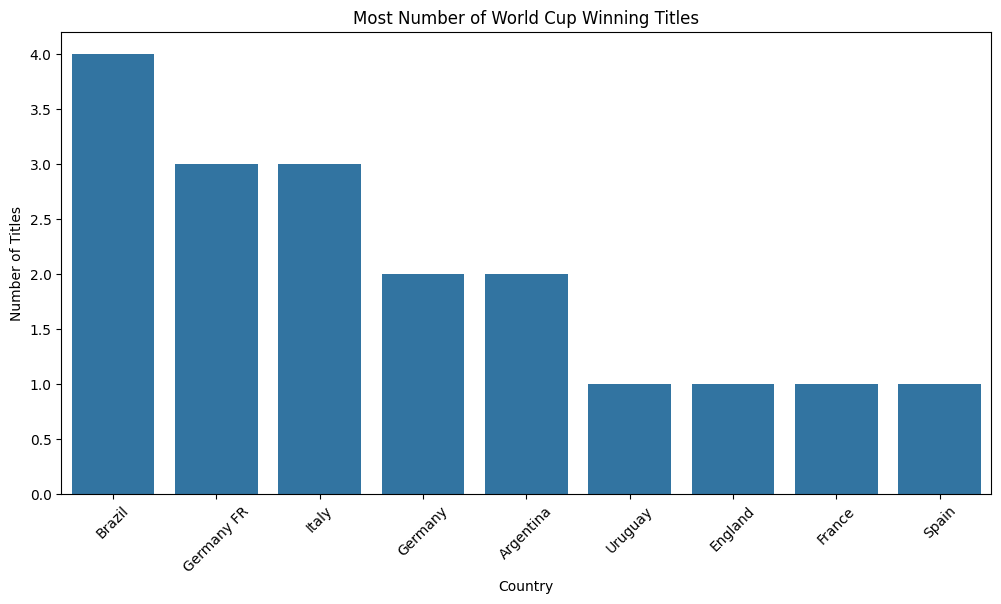

In [ ]:

# Step 4: Visualisasi

# 1. Most Number of World Cup Winning Titles
final_matches = df_clean[df_clean['Stage'].str.lower() == 'final']
winners = final_matches[final_matches['Match Winner'] != "Draw"]["Match Winner"].value_counts()
plt.figure(figsize=(12,6))
sns.barplot(x=winners.index, y=winners.values)
plt.title("Most Number of World Cup Winning Titles")
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

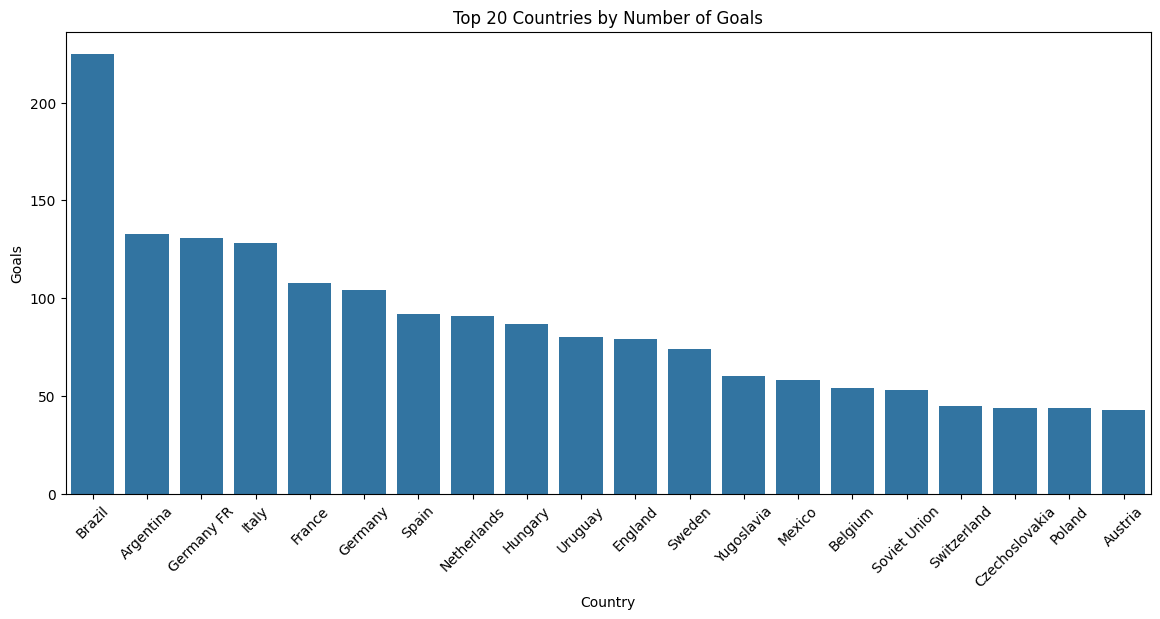

In [ ]:
# 2. Number of Goals Per Country
home_goals = df_clean.groupby("Home Team Name")["Home Team Goals"].sum()
away_goals = df_clean.groupby("Away Team Name")["Away Team Goals"].sum()
total_goals = home_goals.add(away_goals, fill_value=0).sort_values(ascending=False)
plt.figure(figsize=(14,6))
sns.barplot(x=total_goals.index[:20], y=total_goals.values[:20])
plt.title("Top 20 Countries by Number of Goals")
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Goals")
plt.show()


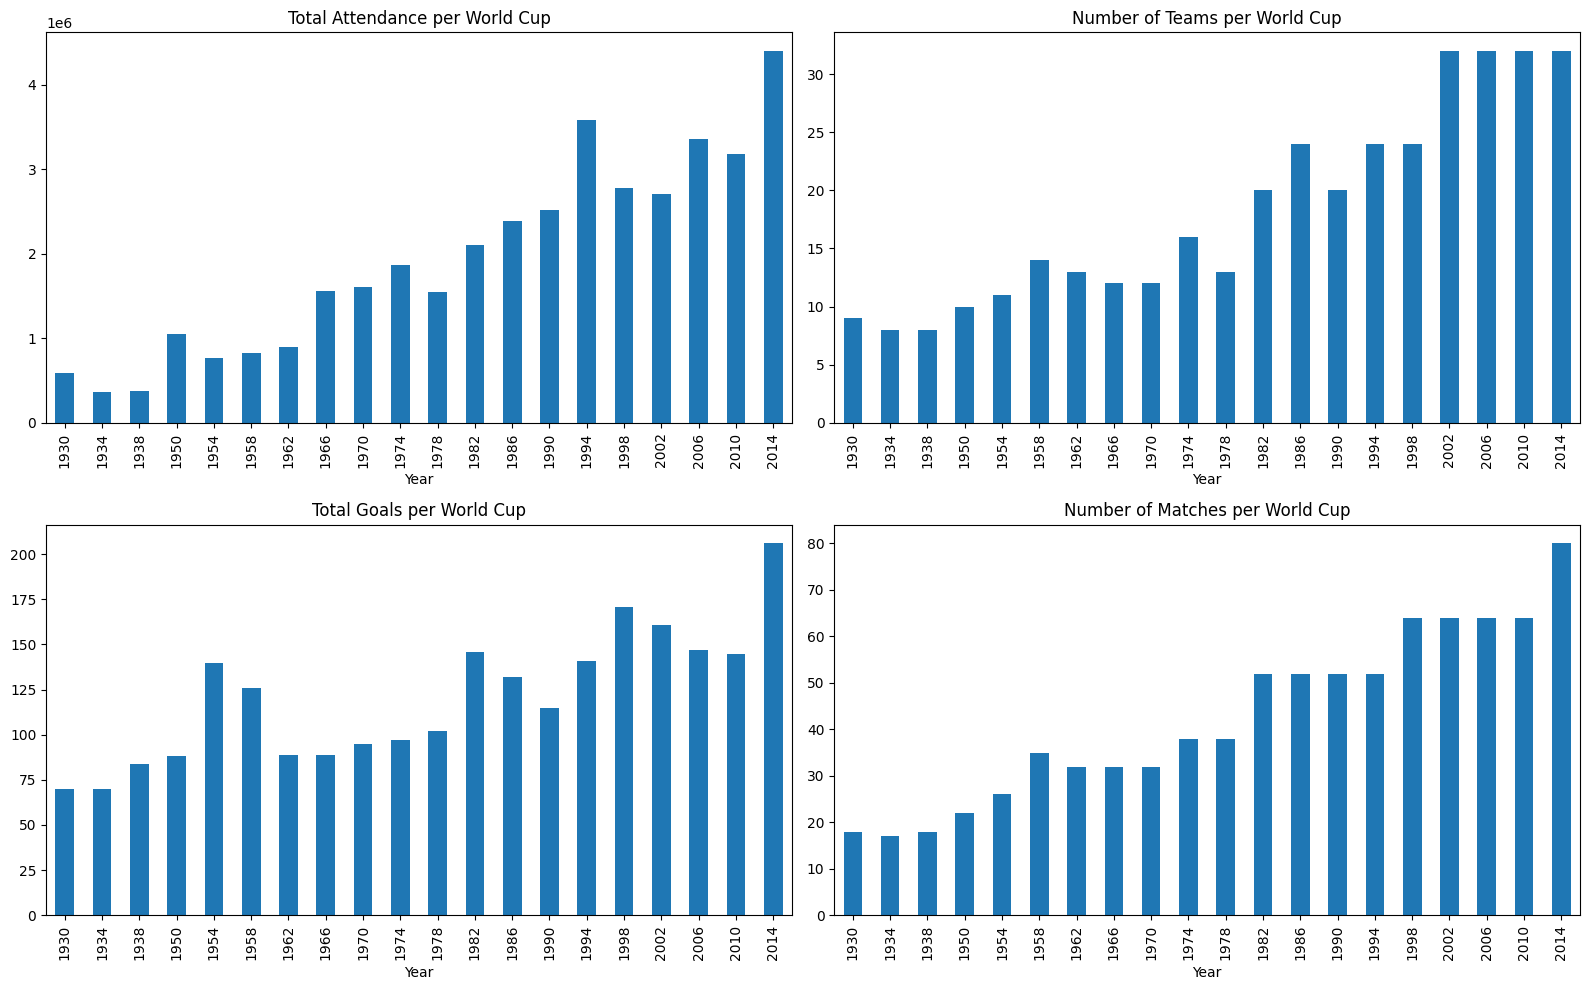

In [ ]:
# 3. Attendance, Number of Teams, Goals, and Matches per Cup
summary_per_year = df_clean.groupby("Year").agg({
    "Attendance": "sum",
    "Home Team Name": lambda x: pd.unique(x).size,
    "MatchID": "count",
    "Home Team Goals": "sum",
    "Away Team Goals": "sum"
})
summary_per_year.rename(columns={
    "Attendance": "Total Attendance",
    "Home Team Name": "Number of Teams",
    "MatchID": "Number of Matches",
    "Home Team Goals": "Home Goals",
    "Away Team Goals": "Away Goals"
}, inplace=True)
summary_per_year["Total Goals"] = summary_per_year["Home Goals"] + summary_per_year["Away Goals"]

fig, ax = plt.subplots(2, 2, figsize=(16, 10))
summary_per_year["Total Attendance"].plot(kind='bar', ax=ax[0][0], title="Total Attendance per World Cup")
summary_per_year["Number of Teams"].plot(kind='bar', ax=ax[0][1], title="Number of Teams per World Cup")
summary_per_year["Total Goals"].plot(kind='bar', ax=ax[1][0], title="Total Goals per World Cup")
summary_per_year["Number of Matches"].plot(kind='bar', ax=ax[1][1], title="Number of Matches per World Cup")
plt.tight_layout()
plt.show()



In [ ]:
# 4. Match with Highest Number of Attendance
highest_attendance = df_clean[df_clean["Attendance"] == df_clean["Attendance"].max()]

highest_attendance_display = highest_attendance[[
    "Year", "City", "Stadium", "Home Team Name", "Away Team Name",
    "Home Team Goals", "Away Team Goals", "Attendance"
]]

highest_attendance_display


,Year,City,Stadium,Home Team Name,Away Team Name,Home Team Goals,Away Team Goals,Attendance
74,1950,Rio De Janeiro,Maracan� - Est�dio Jornalista M�rio Filho,Uruguay,Brazil,2.0,1.0,173850.0


<ipython-input-27-4056577747>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_stadiums.values, y=top_stadiums.index, palette="crest")


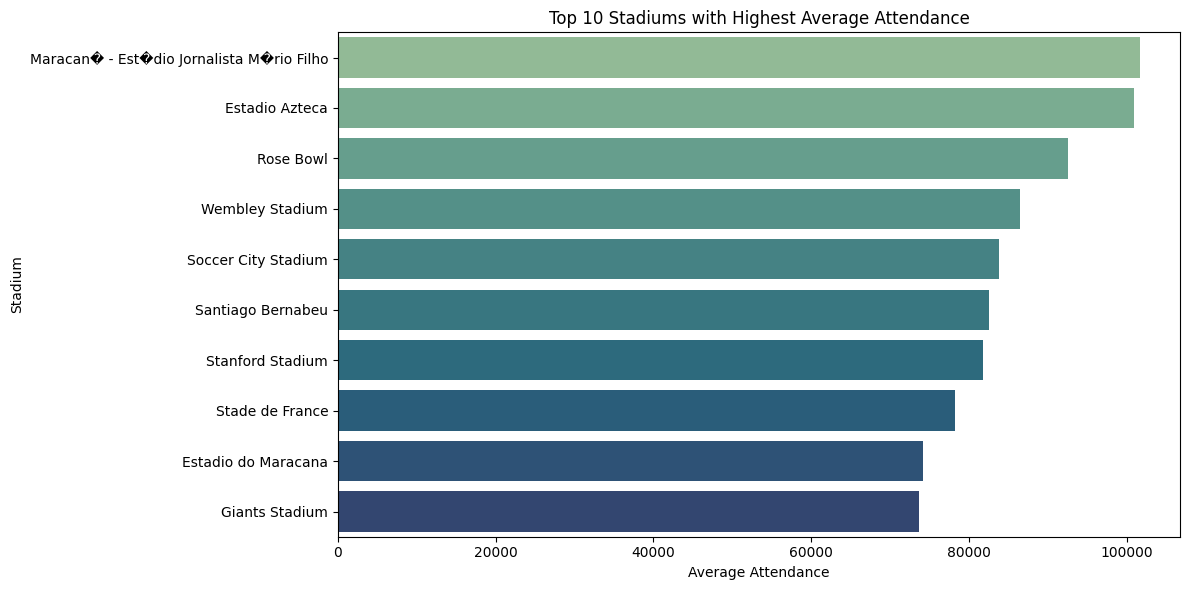

In [ ]:
# 5. Stadium with Highest Average Attendance
avg_attendance_stadium = df_clean.groupby("Stadium")["Attendance"].mean().sort_values(ascending=False)

top_stadiums = avg_attendance_stadium.head(10)

# Plot
plt.figure(figsize=(12,6))
sns.barplot(x=top_stadiums.values, y=top_stadiums.index, palette="crest")
plt.title("Top 10 Stadiums with Highest Average Attendance")
plt.xlabel("Average Attendance")
plt.ylabel("Stadium")
plt.tight_layout()
plt.show()


<ipython-input-22-3365666574>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette="pastel")


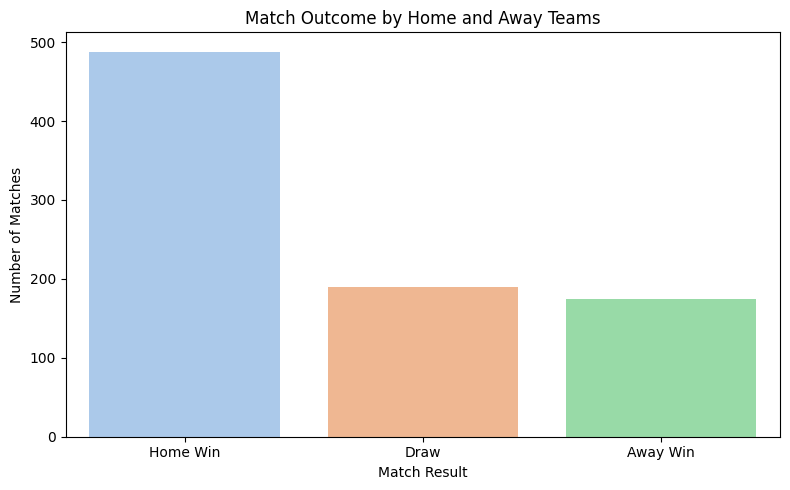

In [ ]:
# 6. Match outcome by home and away teams
results = df_clean.copy()

results["Outcome"] = results.apply(
    lambda row: "Home Win" if row["Home Team Goals"] > row["Away Team Goals"]
    else "Away Win" if row["Home Team Goals"] < row["Away Team Goals"]
    else "Draw", axis=1
)

outcome_counts = results["Outcome"].value_counts()

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values, palette="pastel")
plt.title("Match Outcome by Home and Away Teams")
plt.xlabel("Match Result")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()
